In [28]:
# import librerias
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

### Parte 1: 
Para imágenes en /assets/white_patch

1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de
White patch.

In [38]:
# Obtención de imagenes dentro de white_patch 
img_list = sorted(glob.glob("../assets/white_patch/*"))

Valor máximo del canal R,G,B: 165, 138, 200; Max o Percentil 99: 165, 138, 200


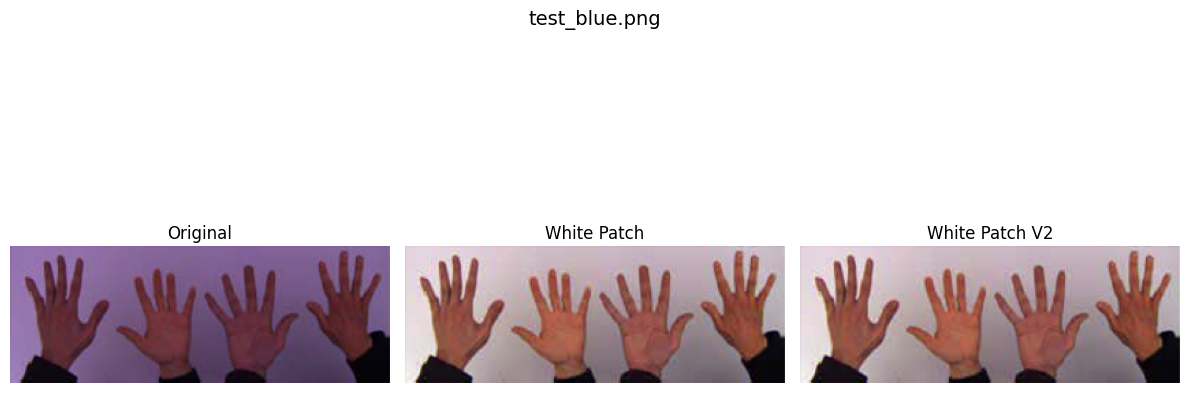

Valor máximo del canal R,G,B: 210, 250, 171; Max o Percentil 99: 210, 226.0, 171


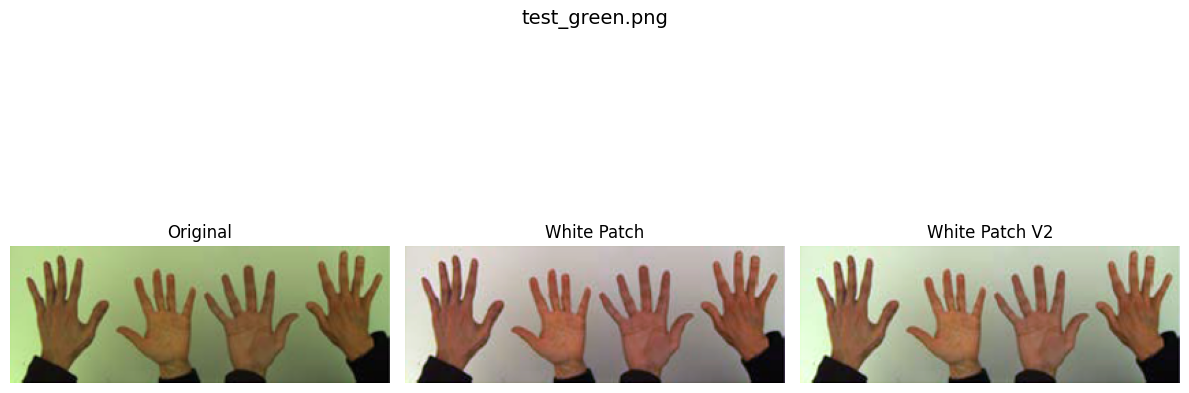

Valor máximo del canal R,G,B: 247, 157, 175; Max o Percentil 99: 228.0, 157, 175


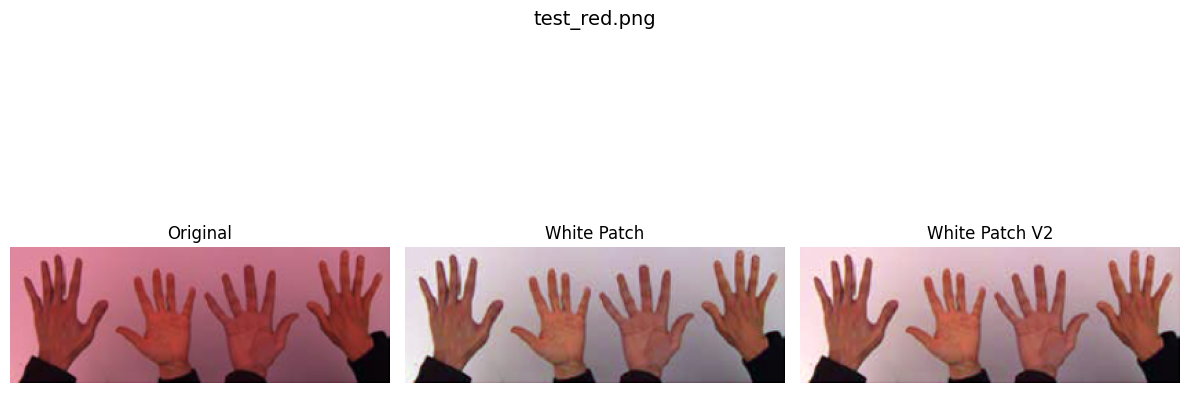

Valor máximo del canal R,G,B: 255, 255, 255; Max o Percentil 99: 86.0, 69.0, 253.0


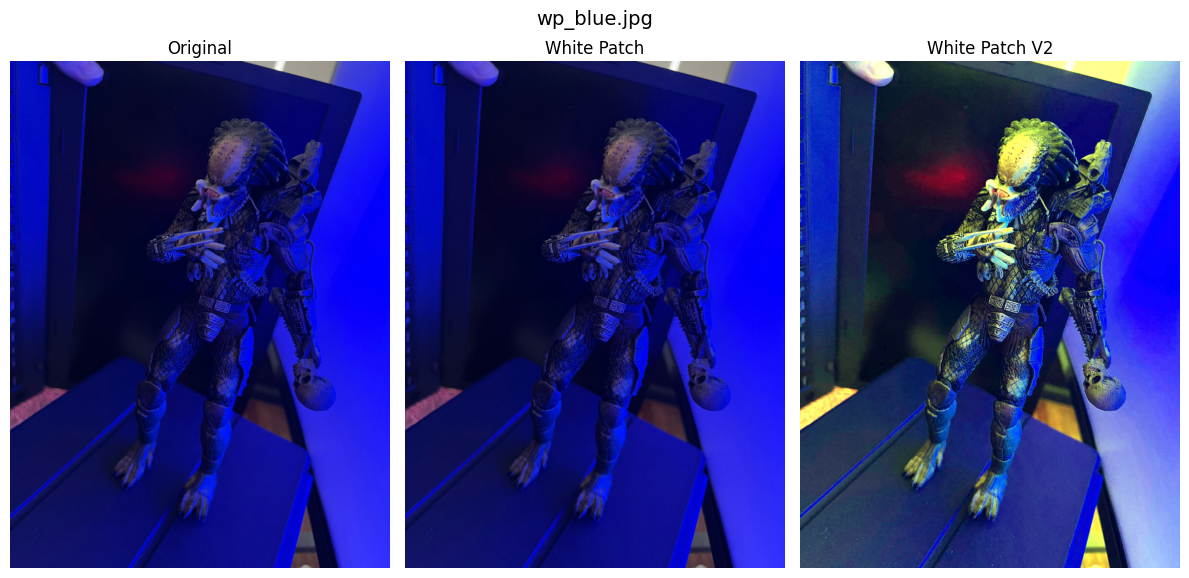

Valor máximo del canal R,G,B: 126, 252, 155; Max o Percentil 99: 126, 242.0, 155


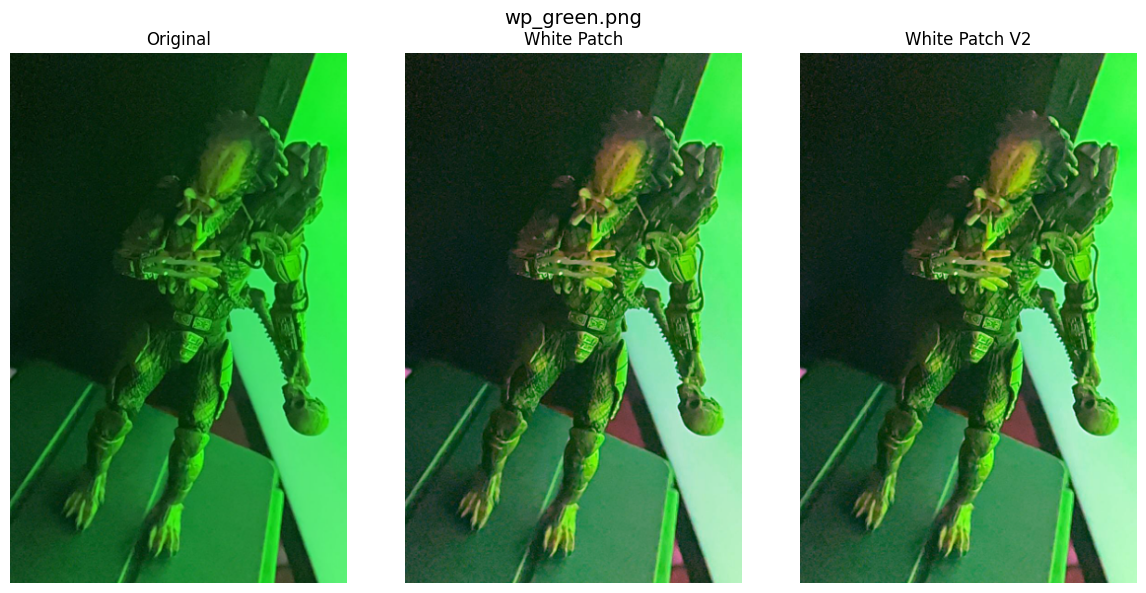

Valor máximo del canal R,G,B: 170, 255, 172; Max o Percentil 99: 170, 255.0, 172


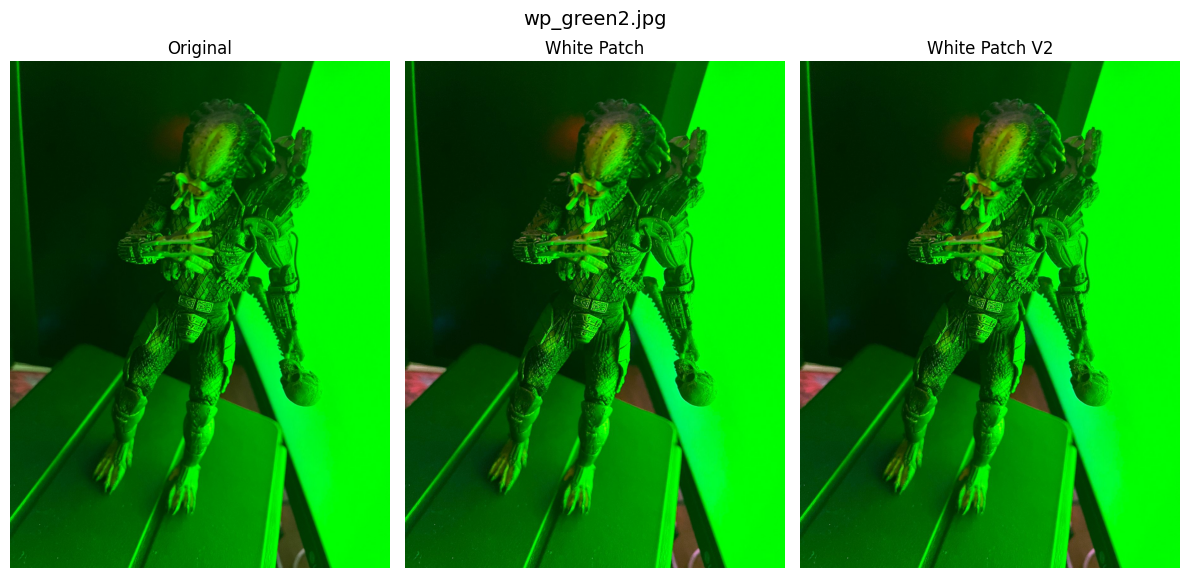

Valor máximo del canal R,G,B: 255, 134, 122; Max o Percentil 99: 255.0, 134, 122


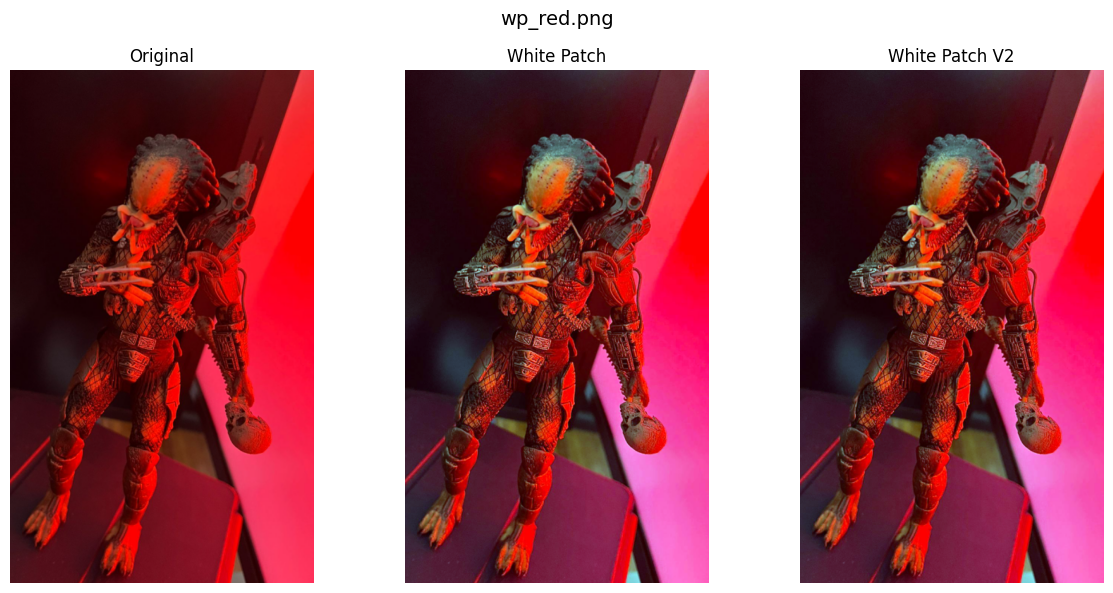

Valor máximo del canal R,G,B: 255, 201, 203; Max o Percentil 99: 255.0, 201, 203


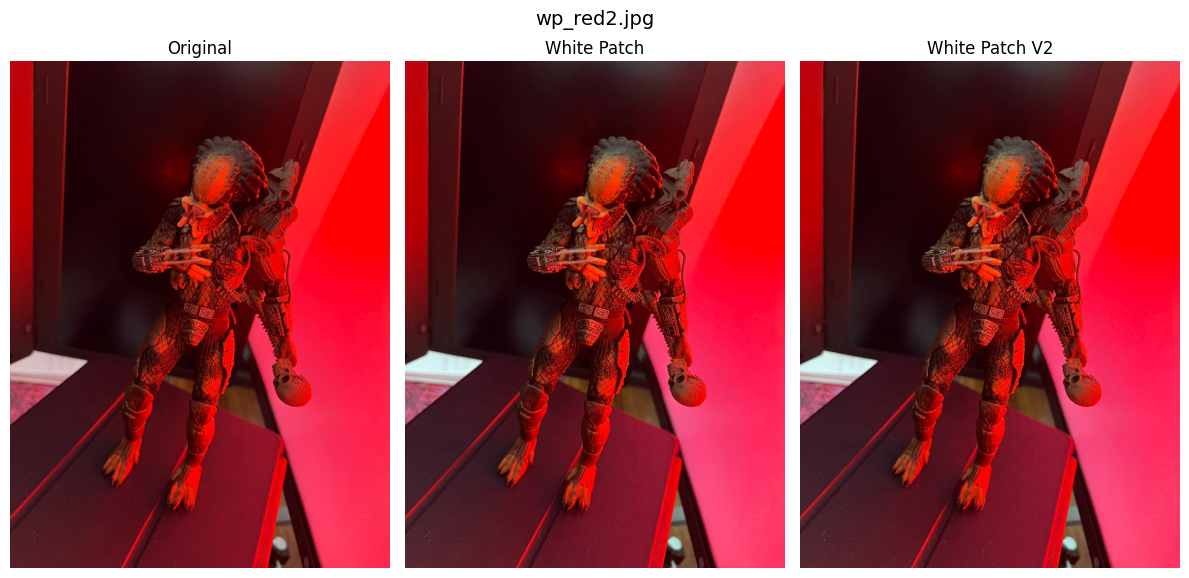

In [ ]:
max_threshold_r = 230
max_threshold_g = 230
max_threshold_b = 230



for path in img_list:
    # Para cada canal RGB, se obtiene valor máximo y se calcula 255/max. Luego se multiplican los canales por el factor. 
    # Calculo de valores máximos por canal. 
    img = cv2.imread(path)
    # De BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    im_r, im_g, im_b = cv2.split(img)

    # Obtener valor máximo de matríz r_channel 
    r_max = np.max(im_r)
    # Calculo de factor de corrección 
    r_factor = 255 / r_max
    # Version 2. Si está muy cerca de 255 se aplica un factor para evitar 255/255 = 1.
    if r_max >= max_threshold_r:
        r_max_v2 = np.percentile(im_r, 98)
        r_factor_v2 = 255 / r_max_v2
    else:
        r_max_v2 = r_max
        r_factor_v2 = r_factor

    # Obtener valor máximo de matríz g_channel 
    g_max = np.max(im_g)
    # Calculo de factor de corrección 
    g_factor = 255 / g_max
    if g_max >= max_threshold_g:
        g_max_v2 = np.percentile(im_g, 98)
        g_factor_v2 = 255 / g_max_v2
    else:
        g_max_v2 = g_max
        g_factor_v2 = g_factor

    # Obtener valor máximo de matríz b_channel 
    b_max = np.max(im_b)
    # Calculo de factor de corrección 
    b_factor = 255 / b_max
    if b_max >= max_threshold_b:
        b_max_v2 = np.percentile(im_b, 98)
        b_factor_v2 = 255 / b_max_v2
    else:
        b_max_v2 = b_max
        b_factor_v2 = b_factor

    # print valores 
    print(f"Valor máximo del canal R,G,B: {r_max}, {g_max}, {b_max}; Max o Percentil 99: {r_max_v2}, {g_max_v2}, {b_max_v2}")

    '''
    # print 
    print(f"Factor de corrección para el canal R: {r_factor}")
    print(f"Factor de corrección para el canal G: {g_factor}")
    print(f"Factor de corrección para el canal B: {b_factor}")
    '''

    # Aplicación de factor. Se clipea el resultado para evitar valores mayores a 255.
    img_processed =cv2.merge((np.uint8(im_r * r_factor), np.uint8(im_g * g_factor), np.uint8(im_b * b_factor)))
    img_processed_v2 = cv2.merge((np.clip(im_r.astype(np.float32)*r_factor_v2, 0, 255).astype(np.uint8),np.clip(im_g.astype(np.float32)*g_factor_v2, 0, 255).astype(np.uint8),np.clip(im_b.astype(np.float32)*b_factor_v2, 0, 255).astype(np.uint8),))

    fig, axs = plt.subplots(1, 3, figsize=(12, 6))
    axs[0].imshow(img); axs[0].set_title("Original"); axs[0].axis("off")
    axs[1].imshow(img_processed); axs[1].set_title("White Patch"); axs[1].axis("off")
    axs[2].imshow(img_processed_v2); axs[2].set_title("White Patch V2"); axs[2].axis("off")

    fig.suptitle(path.split("/")[-1], fontsize=14)
    plt.tight_layout()
    plt.show()

#### Conclusiones 

Se pueden ver encima los resultados y el código utilizado para la implementación del algoritmo white patch. Además, se genero una segunda variante del mismo que se justificará en esta conclusión. 

En las imágenes `test_blue.png`, `test_green.png`, `test_red.png` se puede ver que el algoritmo white patch funciona bastante bien, recuperando y corrigiendo las imágenes al punto que se ven bastante similares entre sí luego de ser procesadas por el algoritmo. 

Por otro lado, el resto de imágenes con la figura, debido a la intensidad de las luces con las que se iluminó al momento de la fotografía es menos efectivo en su tratamiento el algoritmo debido a que es muy sensible a outliers. Estas imágenes tienen partes donde se pueden ver pixeles cercanos al blanco que hacen que no se modifiquen realmente los pixeles en magnitud considerable. 

Por este mismo motivo, se implementó una variación que toma en vez del máximo el percentil 98, cuyo impacto se puede ver visiblemente en la imagen `wp_blue.jpg`, que mejora bastante luego de esta implementación. 

### Parte 2

1. Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grisas y
visualizarlas.
2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas
entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección
de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

In [48]:
# Obtenemos las imagenes
img1 = cv2.imread("../assets/img1_tp.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("../assets/img2_tp.png", cv2.IMREAD_GRAYSCALE)

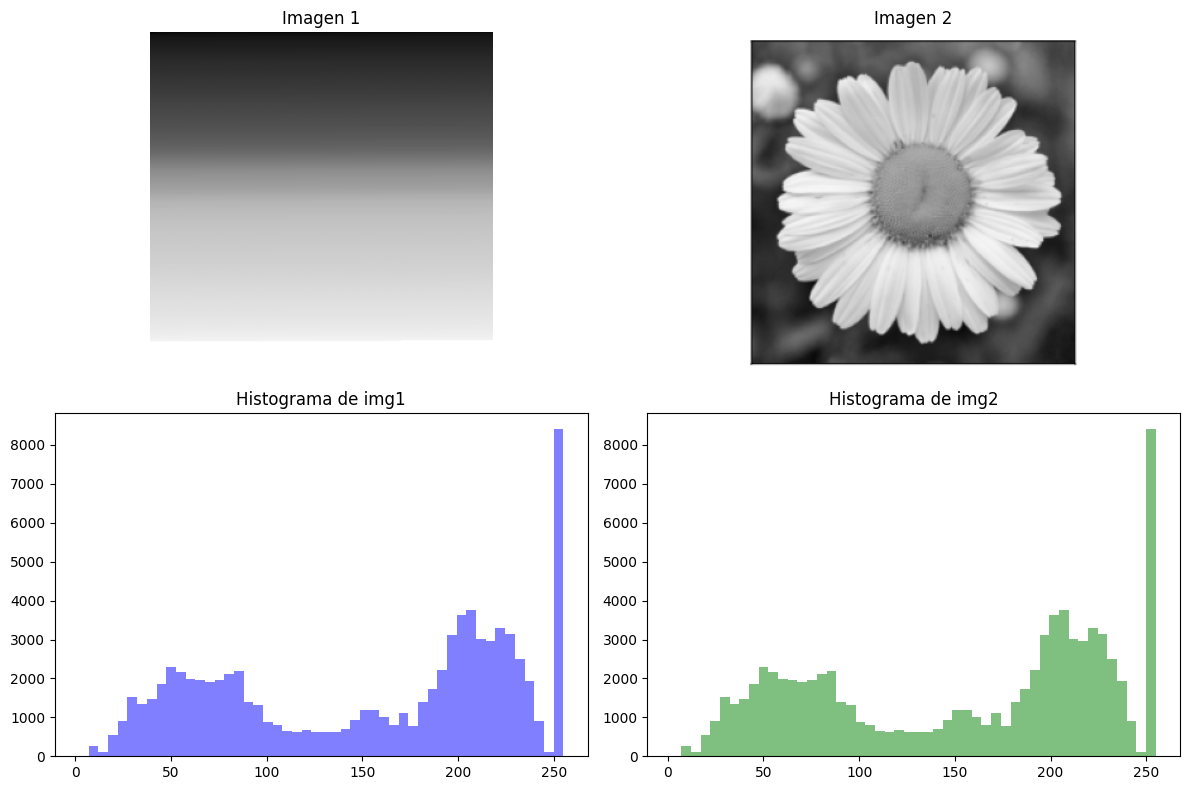

In [50]:
# Histogramas de imagenes en escala de grises con 50 bins. Con fotos verdaderas por encima
plt.figure(figsize=(12, 8))

# ---- Fila 1: imágenes ----
plt.subplot(2, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title("Imagen 1")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title("Imagen 2")
plt.axis("off")

# ---- Fila 2: histogramas ----
plt.subplot(2, 2, 3)
plt.hist(img1.ravel(), bins=50, color='blue', alpha=0.5)
plt.title("Histograma de img1")

plt.subplot(2, 2, 4)
plt.hist(img2.ravel(), bins=50, color='green', alpha=0.5)
plt.title("Histograma de img2")

plt.tight_layout()
plt.show()

#### Conclusión 

Lo que podemos observar de estos histogramas es que son prácticamente iguales en su distribución normalizada. Podemos concluir en base a esto que no se puede depender **únicamente** de la frecuencia de pixeles en rangos de densidad para extracción de datos para clasificación/detección. 

No se podría concluir sin embargo que no sea de utilidad en conjunto con otras herramientas o datos de la imagen, por ejemplo features que tengan en cuenta no solo la intensidad de los píxeles si no también su posición o distribución.